In [3]:
import pandas as pd

df = pd.read_csv('../data/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print(df['TARGET'].value_counts())
print(df['TARGET'].value_counts(normalize=True))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [5]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(20))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


In [6]:
print(df.dtypes.value_counts())

float64    65
int64      41
str        16
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


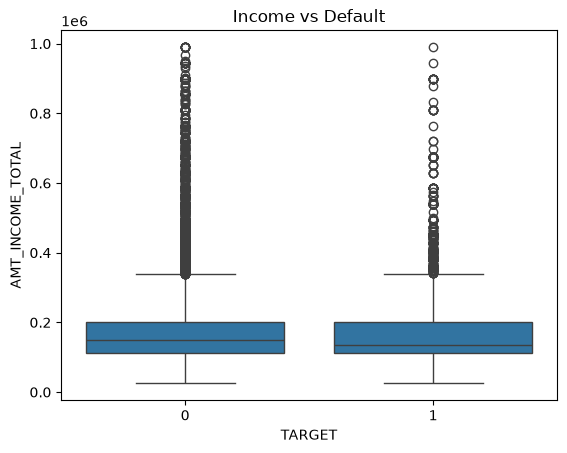

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df[df['AMT_INCOME_TOTAL'] < 1_000_000]

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=plot_df)
plt.title('Income vs Default')
plt.show()


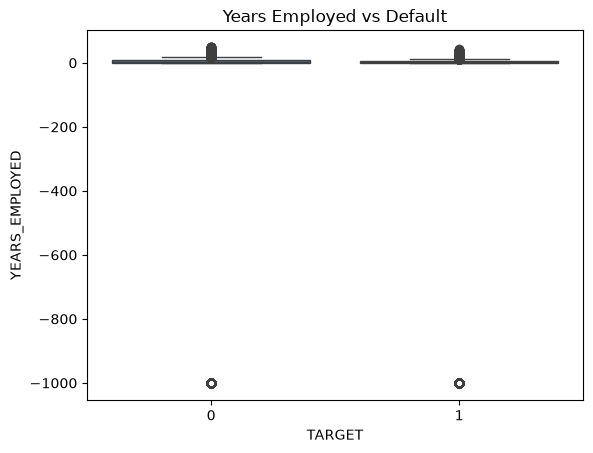

In [8]:
plot_df = df[df['AMT_INCOME_TOTAL'] < 1_000_000].copy()
plot_df['YEARS_EMPLOYED'] = -plot_df['DAYS_EMPLOYED'] / 365
plot_df = plot_df[plot_df['YEARS_EMPLOYED'] < 50]

sns.boxplot(x='TARGET', y='YEARS_EMPLOYED', data=plot_df)
plt.title('Years Employed vs Default')
plt.show()

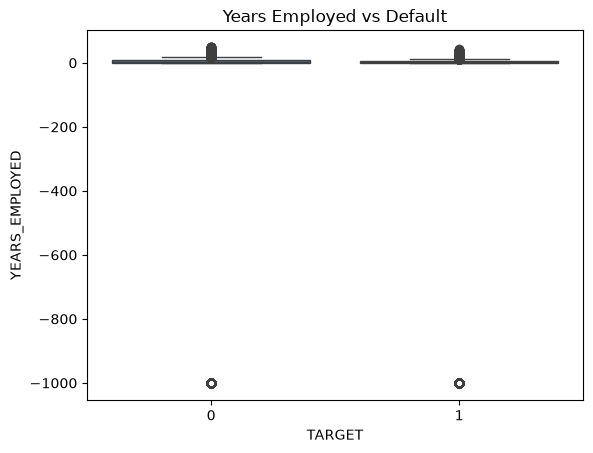

In [9]:
plot_df = df[df['AMT_INCOME_TOTAL'] < 1_000_000].copy()
plot_df['YEARS_EMPLOYED'] = -plot_df['DAYS_EMPLOYED'] / 365
plot_df = plot_df[plot_df['YEARS_EMPLOYED'] < 50]

sns.boxplot(x='TARGET', y='YEARS_EMPLOYED', data=plot_df)
plt.title('Years Employed vs Default')
plt.show()

In [10]:
features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_FAM_MEMBERS',
    'NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
]

df_model = df[features + ['TARGET']].copy()
df_model.shape

(307511, 12)

In [11]:
df_model['AGE_YEARS'] = -df_model['DAYS_BIRTH'] / 365
df_model['YEARS_EMPLOYED'] = -df_model['DAYS_EMPLOYED'] / 365

# fix the same anomaly we caught earlier (365243 bug value -> negative years)
df_model.loc[df_model['YEARS_EMPLOYED'] < 0, 'YEARS_EMPLOYED'] = 0

df_model.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

df_model[['AGE_YEARS', 'YEARS_EMPLOYED']].describe()

,AGE_YEARS,YEARS_EMPLOYED
count,307511.000000,307511.000000
mean,43.936973,5.355748
std,11.956133,6.320737
min,20.517808,0.000000
25%,34.008219,0.791781
50%,43.150685,3.323288
75%,53.923288,7.561644
max,69.120548,49.073973


In [12]:
import numpy as np
rng = np.random.default_rng(42)

# Simulated: consistency of utility bill payments (0 = always late, 1 = always on time)
df_model['SIM_UTILITY_PAYMENT_SCORE'] = rng.beta(5, 2, size=len(df_model))

# Simulated: mobile recharge frequency per month
df_model['SIM_RECHARGE_FREQ'] = rng.poisson(4, size=len(df_model))

df_model[['SIM_UTILITY_PAYMENT_SCORE', 'SIM_RECHARGE_FREQ']].describe()

,SIM_UTILITY_PAYMENT_SCORE,SIM_RECHARGE_FREQ
count,307511.000000,307511.000000
mean,0.714647,3.997603
std,0.159681,1.999259
min,0.051652,0.000000
25%,0.610880,3.000000
50%,0.735757,4.000000
75%,0.838906,5.000000
max,0.999467,17.000000


In [13]:
df_model = pd.get_dummies(df_model, columns=[
    'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'CODE_GENDER',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY'
], drop_first=True)

df_model.shape

(307511, 24)

In [14]:
df_model.fillna(df_model.median(numeric_only=True), inplace=True)
print(df_model.isnull().sum().sum())

0


In [15]:
df_model.to_csv('../data/processed_data.csv', index=False)
print("Saved!")

Saved!
